# 12.3 병든 잎사귀 식별 경진대회 베이스라인 모델
- [병든 잎사귀 식별 경진대회 링크](https://www.kaggle.com/c/plant-pathology-2020-fgvc7)
- [베이스라인 모델 코드 참고 링크](https://www.kaggle.com/akasharidas/plant-pathology-2020-in-pytorch)

## 12.3.1 시드값 고정 및 GPU 장비 설정
### 시드값 고정

In [22]:
import torch # 파이토치 
import random
import numpy as np
import os

# 시드값 고정
seed = 50
os.environ['PYTHONHASHSEED'] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

### GPU 장비 설정

In [23]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

device

device(type='cuda')

## 12.3.2 데이터 준비

In [24]:
import pandas as pd

# 데이터 경로
data_path = '/kaggle/input/plant-pathology-2020-fgvc7/'

train = pd.read_csv(data_path + 'train.csv')
test = pd.read_csv(data_path + 'test.csv')
submission = pd.read_csv(data_path + 'sample_submission.csv')

### 훈련 데이터, 검증 데이터 분리

In [25]:
from sklearn.model_selection import train_test_split

# 훈련 데이터, 검증 데이터 분리
train, valid = train_test_split(train, 
                                test_size=0.1,
                                stratify=train[['healthy', 'multiple_diseases', 'rust', 'scab']],
                                random_state=50)

모듈1: 증강 기법 탐구

테스트 이미지 ID: Train_1084
실험적 증강 파이프라인 적용 결과 (원본 vs 증강):


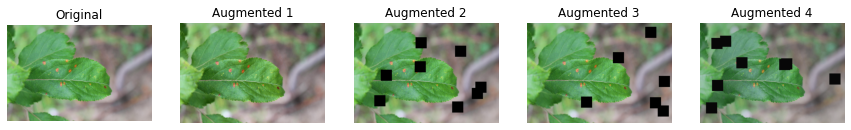

In [26]:
import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np

# --- [1. 증강 시각화 도구 함수 정의] ---
def visualize_augmentations(img_id, transform, n_examples=4):
    """
    특정 이미지(img_id)에 transform 파이프라인을 n_examples번 적용하여 시각화합니다.
    """
    img_path = f'{data_path}images/{img_id}.jpg' # 경로 수정: data_path 끝에 '/'가 있으므로 images 앞에 '/' 제거
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(15, 4))

    plt.subplot(1, n_examples + 1, 1)
    plt.title("Original")
    plt.imshow(image)
    plt.axis('off')

    for i in range(n_examples):
        augmented = transform(image=image)['image']
        plt.subplot(1, n_examples + 1, i + 2)
        plt.title(f"Augmented {i+1}")
        plt.imshow(augmented)
        plt.axis('off')
    plt.show()

# --- [2. 탐구: 나만의 실험적 증강 파이프라인 작성] ---
transform_experimental = A.Compose([
    A.Resize(450, 650),
    A.CoarseDropout(max_holes=8, max_height=50, max_width=50, min_holes=2, p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05, p=0.3),
    A.Transpose(p=0.3),
])

# --- [3. 효과 분석 및 검증] ---
sample_img_id = train[train['rust'] == 1]['image_id'].iloc[0]

print(f"테스트 이미지 ID: {sample_img_id}")
print("실험적 증강 파이프라인 적용 결과 (원본 vs 증강):")

visualize_augmentations(sample_img_id, transform_experimental, n_examples=4)

### 데이터셋 클래스 정의

In [27]:
import cv2
from torch.utils.data import Dataset # 데이터 생성을 위한 클래스
import numpy as np

class ImageDataset(Dataset):
    # 초기화 메서드(생성자)
    def __init__(self, df, img_dir='./', transform=None, is_test=False):
        super().__init__() # 상속받은 Dataset의 __init__() 메서드 호출
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        self.is_test = is_test
    
    # 데이터셋 크기 반환 메서드 
    def __len__(self):
        return len(self.df)
    
    # 인덱스(idx)에 해당하는 데이터 반환 메서드
    def __getitem__(self, idx):
        img_id = self.df.iloc[idx, 0]             # 이미지 ID
        img_path = self.img_dir + img_id + '.jpg' # 이미지 파일 경로
        image = cv2.imread(img_path)              # 이미지 파일 읽기
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) # 이미지 색상 보정
        # 이미지 변환 
        if self.transform is not None:
            image = self.transform(image=image)['image']
        # 테스트 데이터면 이미지 데이터만 반환, 그렇지 않으면 타깃값도 반환 
        if self.is_test:
            return image # 테스트용일 때
        else:
            # 타깃값 4개 중 가장 큰 값의 인덱스 
            label = np.argmax(self.df.iloc[idx, 1:5]) 
            return image, label # 훈련/검증용일 때

### 이미지 변환기 정의

In [28]:
# 이미지 변환을 위한 모듈
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [29]:
# 훈련 데이터용 변환기
transform_train = A.Compose([
    A.Resize(450, 650),       # 이미지 크기 조절 
    A.RandomBrightnessContrast(brightness_limit=0.2, # 밝기 대비 조절
                               contrast_limit=0.2, p=0.3),
    A.VerticalFlip(p=0.2),    # 상하 대칭 변환
    A.HorizontalFlip(p=0.5),  # 좌우 대칭 변환 
    A.ShiftScaleRotate(       # 이동, 스케일링, 회전 변환
        shift_limit=0.1,
        scale_limit=0.2,
        rotate_limit=30, p=0.3),
    A.OneOf([A.Emboss(p=1),   # 양각화, 날카로움, 블러 효과
             A.Sharpen(p=1),
             A.Blur(p=1)], p=0.3),
    A.PiecewiseAffine(p=0.3), # 어파인 변환 
    A.Normalize(),            # 정규화 변환 
    ToTensorV2()              # 텐서로 변환
])

In [30]:
# 검증 및 테스트 데이터용 변환기
transform_test = A.Compose([
    A.Resize(450, 650), # 이미지 크기 조절 
    A.Normalize(),      # 정규화 변환
    ToTensorV2()        # 텐서로 변환
])

### 데이터셋 및 데이터 로더 생성

In [31]:
img_dir = '/kaggle/input/plant-pathology-2020-fgvc7/images/'

dataset_train = ImageDataset(train, img_dir=img_dir, transform=transform_train)
dataset_valid = ImageDataset(valid, img_dir=img_dir, transform=transform_test)

In [32]:
def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    
g = torch.Generator()
g.manual_seed(0)

In [33]:
from torch.utils.data import DataLoader # 데이터 로더 클래스

batch_size = 4

loader_train = DataLoader(dataset_train, batch_size=batch_size, 
                          shuffle=True, worker_init_fn=seed_worker,
                          generator=g, num_workers=2)
loader_valid = DataLoader(dataset_valid, batch_size=batch_size, 
                          shuffle=False, worker_init_fn=seed_worker,
                          generator=g, num_workers=2)

## 12.3.3 모델 생성

### EfficientNet 모델 생성

In [34]:
!pip install efficientnet-pytorch==0.7.1

In [35]:
from efficientnet_pytorch import EfficientNet # EfficientNet 모델

In [36]:
# 사전 훈련된 efficientnet-b7 모델 불러오기
model = EfficientNet.from_pretrained('efficientnet-b7', num_classes=4) 

model = model.to(device) # 장비 할당

Loaded pretrained weights for efficientnet-b7


## 12.3.4 모델 훈련 및 성능 검증

### 손실 함수와 옵티마이저 설정

In [37]:
import torch.nn as nn # 신경망 모듈

# 손실 함수
criterion = nn.CrossEntropyLoss()

In [38]:
# 옵티마이저
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00006, weight_decay=0.0001)

### 훈련 및 성능 검증

In [39]:
from sklearn.metrics import roc_auc_score # ROC AUC 점수 계산 함수
from tqdm import tqdm # 진행률 표시 막대 

epochs = 5

# 총 에폭만큼 반복
for epoch in range(epochs):
    # == [ 훈련 ] ==============================================
    model.train()        # 모델을 훈련 상태로 설정 
    epoch_train_loss = 0 # 에폭별 손실값 초기화 (훈련 데이터용)
    
    # '반복 횟수'만큼 반복 
    for images, labels in tqdm(loader_train):
        # 이미지, 레이블(타깃값) 데이터 미니배치를 장비에 할당 
        images = images.to(device)
        labels = labels.to(device)
        
        # 옵티마이저 내 기울기 초기화
        optimizer.zero_grad()
        # 순전파 : 이미지 데이터를 신경망 모델의 입력값으로 사용해 출력값 계산
        outputs = model(images)
        # 손실 함수를 활용해 outputs와 labels의 손실값 계산
        loss = criterion(outputs, labels)
        # 현재 배치에서의 손실 추가 (훈련 데이터용)
        epoch_train_loss += loss.item() 
        loss.backward() # 역전파 수행
        optimizer.step() # 가중치 갱신
    # 훈련 데이터 손실값 출력
    print(f'에폭 [{epoch+1}/{epochs}] - 훈련 데이터 손실값 : {epoch_train_loss/len(loader_train):.4f}')
    
    # == [ 검증 ] ==============================================
    model.eval()          # 모델을 평가 상태로 설정 
    epoch_valid_loss = 0  # 에폭별 손실값 초기화 (검증 데이터용)
    preds_list = []       # 예측 확률값 저장용 리스트 초기화 
    true_onehot_list = [] # 실제 타깃값 저장용 리스트 초기화 
    
    with torch.no_grad(): # 기울기 계산 비활성화
        # 미니배치 단위로 검증
        for images, labels in loader_valid:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            epoch_valid_loss += loss.item()
            
            preds = torch.softmax(outputs.cpu(), dim=1).numpy() # 예측 확률값
            # 실제값 (원-핫 인코딩 형식)
            true_onehot = torch.eye(4)[labels].cpu().numpy()  
            # 예측 확률값과 실제값 저장
            preds_list.extend(preds)
            true_onehot_list.extend(true_onehot)
    # 검증 데이터 손실값 및 ROC AUC 점수 출력 
    print(f'에폭 [{epoch+1}/{epochs}] - 검증 데이터 손실값 : {epoch_valid_loss/len(loader_valid):.4f} / 검증 데이터 ROC AUC : {roc_auc_score(true_onehot_list, preds_list):.4f}')  

100%|██████████| 410/410 [05:49<00:00,  1.17it/s]

에폭 [1/5] - 훈련 데이터 손실값 : 0.6953


에폭 [1/5] - 검증 데이터 손실값 : 0.2325 / 검증 데이터 ROC AUC : 0.9676


100%|██████████| 410/410 [05:49<00:00,  1.17it/s]

에폭 [2/5] - 훈련 데이터 손실값 : 0.3465


...

에폭 [4/5] - 훈련 데이터 손실값 : 0.1613


에폭 [4/5] - 검증 데이터 손실값 : 0.2363 / 검증 데이터 ROC AUC : 0.9792


100%|██████████| 410/410 [05:51<00:00,  1.17it/s]

에폭 [5/5] - 훈련 데이터 손실값 : 0.1556


에폭 [5/5] - 검증 데이터 손실값 : 0.1905 / 검증 데이터 ROC AUC : 0.9659


## 12.3.5 예측 및 결과 제출

In [40]:
dataset_test = ImageDataset(test, img_dir=img_dir, 
                            transform=transform_test, is_test=True)
loader_test = DataLoader(dataset_test, batch_size=batch_size, 
                         shuffle=False, worker_init_fn=seed_worker,
                         generator=g, num_workers=2)

### 예측

In [41]:
model.eval() # 모델을 평가 상태로 설정 

preds = np.zeros((len(test), 4)) # 예측값 저장용 배열 초기화

with torch.no_grad():
    for i, images in enumerate(loader_test):
        images = images.to(device)
        outputs = model(images)
        # 타깃 예측 확률 
        preds_part = torch.softmax(outputs.cpu(), dim=1).squeeze().numpy()
        preds[i*batch_size:(i+1)*batch_size] += preds_part

### 결과 제출

In [42]:
submission[['healthy', 'multiple_diseases', 'rust', 'scab']] = preds
submission.to_csv('submission.csv', index=False)